# Advanced Outlier Detection using Z-Score (3-Sigma Rule)

**Project:** NeoVault Fraud Detection

**Objective:** Identify anomalous transactions using the 3-Sigma (Z-Score) Rule.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import logging
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas

# Configuration for professional logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Import VaultClient for Secure Credential Management
sys.path.append('..') 
from security.vault_client import VaultClient

# 1. Directory Setup
os.makedirs('../results/eda_plots', exist_ok=True)

# 2. Secure Credential Retrieval
try:
    vault = VaultClient()
    secrets = vault.get_snowflake_config()
    logger.info("Credentials retrieved successfully from HashiCorp Vault.")
except Exception as e:
    logger.error(f"Failed to retrieve credentials: {e}")
    sys.exit(1)

# 3. Establish Snowflake Connection (Silver Layer)
conn = snowflake.connector.connect(
    account=secrets['account'],
    user=secrets['user'],
    password=secrets['password'],
    warehouse=secrets['warehouse'],
    database=secrets['database'],
    schema='SILVER'
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')

2026-04-17 14:27:35,989 - INFO - Vault Connection Established: http://localhost:8200
2026-04-17 14:27:36,020 - INFO - Vault Connection Established: http://localhost:8200
2026-04-17 14:27:36,052 - INFO - Credentials retrieved successfully from HashiCorp Vault.
2026-04-17 14:27:36,055 - INFO - Snowflake Connector for Python Version: 4.4.0, Python Version: 3.12.10, Platform: Windows-11-10.0.26200-SP0
2026-04-17 14:27:36,057 - INFO - Connecting to GLOBAL Snowflake domain


## 1. Data Ingestion & Transformation

In [5]:
query = """
    SELECT 
        transaction_id,
        user_id,
        amount,
        timestamp,
        location,
        is_fraud
    FROM FRAUD_DB.SILVER.silver_enriched_transactions
    WHERE timestamp >= DATEADD('day', -30, CURRENT_DATE())
"""

logger.info("Fetching data from Snowflake using Snowflake Connector Engine...")

try:
    cursor = conn.cursor()
    cursor.execute(query)
    df = cursor.fetch_pandas_all()
    
    if df.empty:
        logger.warning("Query successful but returned 0 rows. Check if silver table has data.")
    else:
        # Ensure proper data types
        df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
        df['AMOUNT'] = df['AMOUNT'].astype(float)
        
        df.columns = [col.lower() for col in df.columns]
        
        logger.info(f"Successfully loaded {len(df):,} transactions.")

except Exception as e:
    logger.error(f"Failed to fetch data: {str(e)}")
    df = pd.DataFrame() # Return empty df to prevent crash in next cells

2026-04-17 14:34:21,705 - INFO - Fetching data from Snowflake using Snowflake Connector Engine...
2026-04-17 14:34:22,866 - INFO - Successfully loaded 1,000 transactions.


## 2. Statistical Anomaly Detection (Z-Score)

In [ ]:
# 1. Log transformation
df['amount_log'] = np.log1p(df['amount'])

logger.info("Calculating Z-Scores per user...")

# 2. Calculate mean and std separately for more stability
user_group = df.groupby('user_id')['amount_log']
df['user_mean'] = user_group.transform('mean')
df['user_std'] = user_group.transform('std')

# 3. Calculate Z-Score manually
df['z_score'] = np.where(
    df['user_std'] > 0, 
    (df['amount_log'] - df['user_mean']) / df['user_std'], 
    0
)

# 4. Clear the help column
df.drop(columns=['user_mean', 'user_std'], inplace=True)

# 5. Handle infinite values ​​if any
df['z_score'] = df['z_score'].replace([np.inf, -np.inf], 0).fillna(0)

# 6. Apply 3-Sigma Rule
df['is_outlier'] = np.abs(df['z_score']) > 3
outliers = df[df['is_outlier'] == True].copy()

logger.info(f"Detection complete.")
logger.info(f"Total Transactions: {len(df):,}")
logger.info(f"Outliers Found: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

2026-04-17 14:41:23,745 - INFO - Calculating Z-Scores per user...
2026-04-17 14:41:23,837 - INFO - ✅ Detection complete.
2026-04-17 14:41:23,838 - INFO - Total Transactions: 1,000
2026-04-17 14:41:23,839 - INFO - Outliers Found: 0 (0.00%)


## 3. Visual Analytics

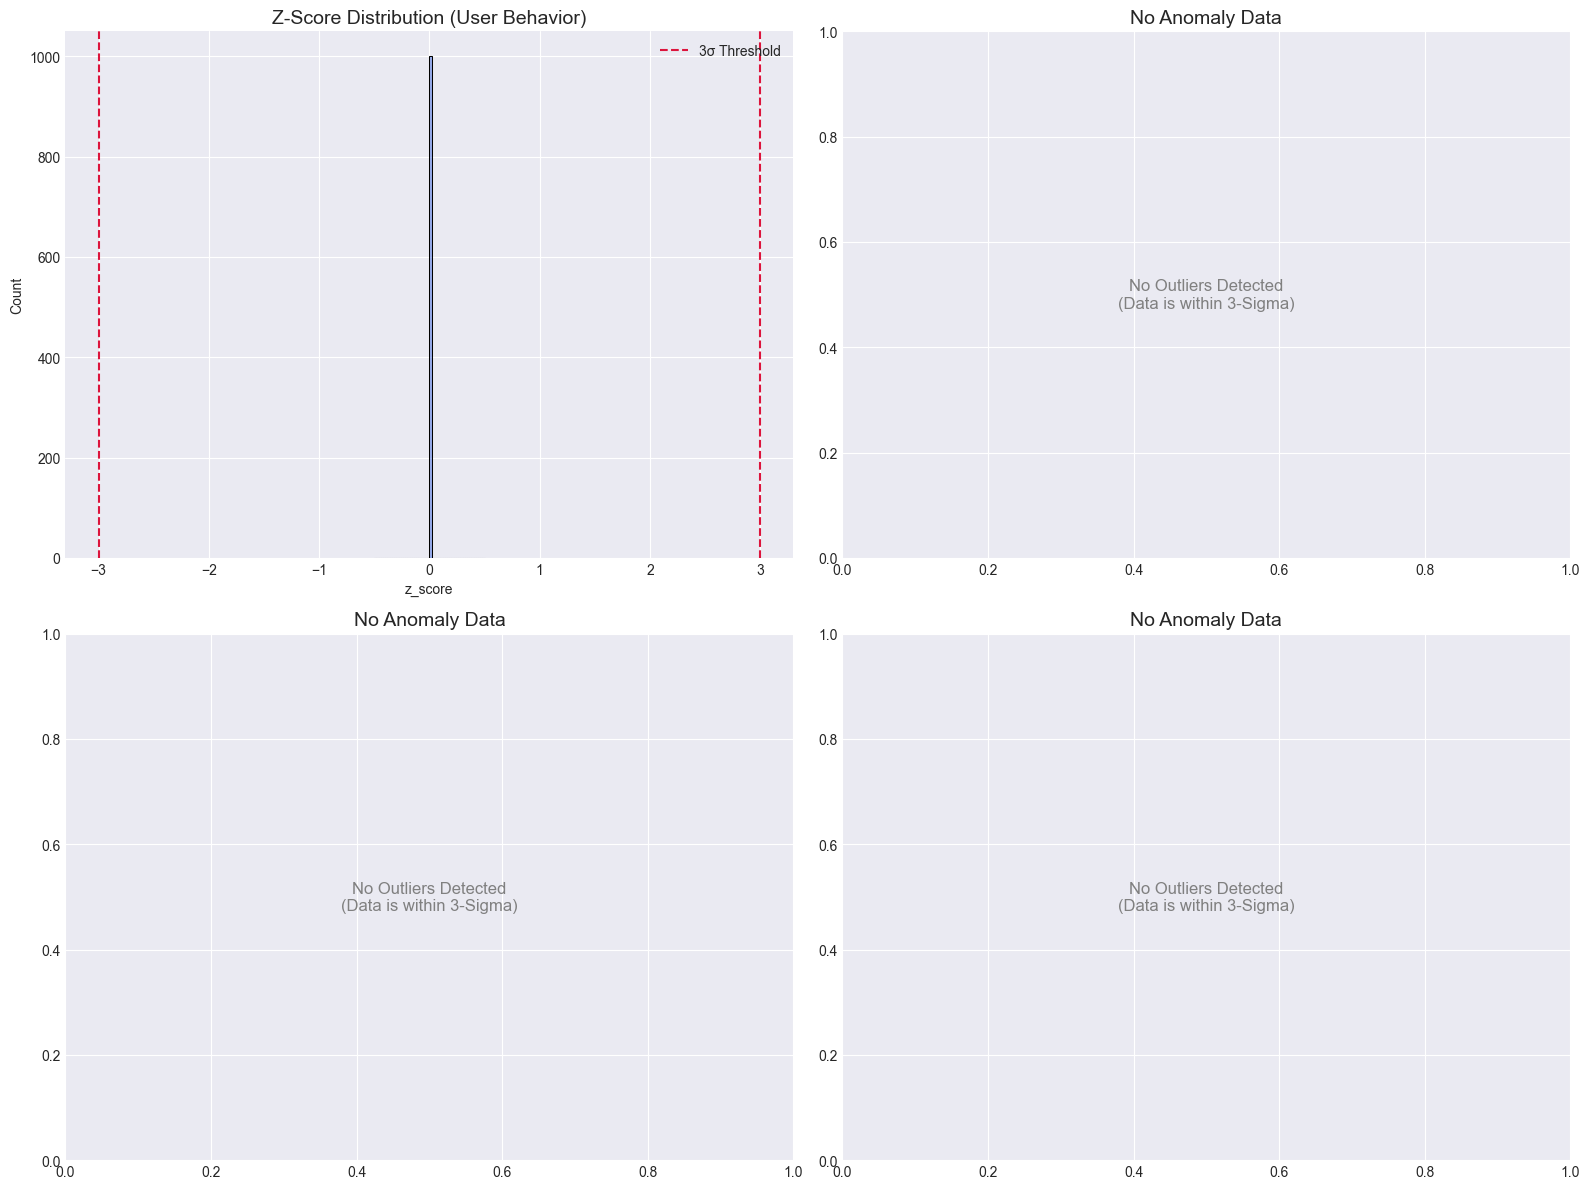

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Z-Score Distribution ---
sns.histplot(df['z_score'], bins=50, kde=True, ax=axes[0,0], color='royalblue')
axes[0,0].axvline(x=3, color='crimson', linestyle='--', label='3σ Threshold')
axes[0,0].axvline(x=-3, color='crimson', linestyle='--')
axes[0,0].set_title('Z-Score Distribution (User Behavior)', fontsize=14)
axes[0,0].legend()

# --- Check for outliers for the remaining plots. ---
if not outliers.empty:
    # Plot 2: Outliers vs Fraud Labels
    outlier_summary = outliers['is_fraud'].value_counts().rename({True: 'Fraud', False: 'Normal'})
    outlier_summary.plot(kind='bar', ax=axes[0,1], color=['orange', 'red'])
    axes[0,1].set_title('Outliers Categorized by Fraud Status', fontsize=14)
    axes[0,1].set_ylabel('Count')

    # Plot 3: Log-Amount Distribution
    sns.boxplot(data=df, x='is_outlier', y='amount', ax=axes[1,0], palette='Set2')
    axes[1,0].set_yscale('log')
    axes[1,0].set_title('Amount Distribution: Outliers vs Normal', fontsize=14)

    # Plot 4: Geographic Hotspots for Outliers
    top_locs = outliers['location'].value_counts().head(10)
    sns.barplot(x=top_locs.values, y=top_locs.index, ax=axes[1,1], palette='Reds_r')
    axes[1,1].set_title('Top 10 Anomaly Locations', fontsize=14)
else:
    for i, j in [(0,1), (1,0), (1,1)]:
        axes[i,j].text(0.5, 0.5, 'No Outliers Detected\n(Data is within 3-Sigma)', 
                       ha='center', va='center', fontsize=12, color='gray')
        axes[i,j].set_title('No Anomaly Data', fontsize=14)

plt.tight_layout()
plt.savefig('../results/eda_plots/outlier_analysis_report.png', dpi=300)
plt.show()

## 4. Synchronizing Results with Snowflake

In [10]:
logger.info("Initializing Outlier Log table in Snowflake...")
cursor = conn.cursor()

cursor.execute("""
    CREATE OR REPLACE TABLE silver_outlier_log (
        transaction_id STRING,
        user_id STRING,
        amount NUMBER(15,2),
        z_score NUMBER(10,4),
        detection_timestamp TIMESTAMP_NTZ DEFAULT CURRENT_TIMESTAMP(),
        is_reviewed BOOLEAN DEFAULT FALSE,
        notes STRING
    )
""")

# Prepare dataframe for Snowflake (Mapping column names correctly)
outlier_to_store = outliers[['transaction_id', 'user_id', 'amount', 'z_score']].copy()
outlier_to_store.columns = [col.upper() for col in outlier_to_store.columns]

# Professional Bulk Insert
try:
    success, nchunks, nrows, _ = write_pandas(conn, outlier_to_store, 'SILVER_OUTLIER_LOG')
    logger.info(f"Successfully synchronized {nrows} outliers to Snowflake.")
except Exception as e:
    logger.error(f"Failed to sync with Snowflake: {e}")

2026-04-17 14:49:03,205 - INFO - Initializing Outlier Log table in Snowflake...
C:\Users\rioal\AppData\Local\Temp\ipykernel_3416\991897037.py:22: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.base.Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, nchunks, nrows, _ = write_pandas(conn, outlier_to_store, 'SILVER_OUTLIER_LOG')
2026-04-17 14:49:08,178 - INFO - Successfully synchronized 0 outliers to Snowflake.


## 5. Operational Alerting

In [11]:
def check_and_alert_outliers(threshold=5):
    """
    Evaluates outlier count and triggers business alerts.
    """
    if len(outliers) > threshold:
        print("\n" + "!"*50)
        print(f"CRITICAL ALERT: {len(outliers)} Anomalies Detected")
        print("!"*50)
        print("\nTop Priority Investigations:")
        print(outliers.nlargest(5, 'amount')[['transaction_id', 'user_id', 'amount', 'z_score']])
        return True
    return False

check_and_alert_outliers()

False